In [1]:
# ── 1. Imports ────────────────────────────────────────────────────────────────
import json
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("../shared").resolve()))
sys.path.insert(0, str(Path(".").resolve()))

from constants import (
    ARM_LINK,
    CAPTIONS_PATH,
    CARTESIAN_CONTROL_CACHE_PATH,
    CARTESIAN_CONTROL_OPTIMAL_RESULTS_PATH,
    CC_A_MAX_EL_NEG,
    CC_A_MAX_EL_POS,
    CC_A_MAX_SH_NEG,
    CC_A_MAX_SH_POS,
    CC_AMP_REG,
    CC_BAND_CHANNELS,
    CC_BAND_SCALE,
    CC_CONSTRAIN_ELBOW,
    CC_DEMO_IDX,
    CC_DEMO_SEED,
    CC_DIST_THRESH,
    CC_EL_HOLD_ALPHA,
    CC_EL_THRESH,
    CC_MIN_PHASE_STEPS,
    CC_MAX_PHASE_STEPS,
    CC_N_R,
    CC_N_THETA,
    CC_OPEN_LOOP_OFFSET,
    CC_OPTIMAL_PARAMS_PATH,
    CC_Q_INT,
    CC_Q_TRACK,
    CC_R_EFFORT,
    CC_SEQ_BLEND_ALPHA,
    CC_SH_DRIFT_THRESH,
    CC_SH_THRESH,
    CC_SH_VEL_DAMP,
    CC_T,
    CC_TARGET_R_MAX,
    CC_TARGET_R_MIN,
    CC_USE_LQI,
    ERA_EM_4_PATH,
    FIGURES_PATH,
    MAX_DELTA,
)
from pgf_utils import (
    apply_figure_style,
    configure_pgf,
    configure_screen,
    figure_inches,
    save_caption,
    save_pgf,
)
from cartesian_control import run_cartesian_control
from cartesian_control_heatmap import (
    NOTEBOOK_GITHUB_URL,
    make_heatmap_figure,
)

In [2]:
# ── 2. Constants ──────────────────────────────────────────────────────────────
# All simulation constants are shared; see notebooks/shared/constants.py.

In [3]:
# ── 3. Derived variables ──────────────────────────────────────────────────────
if CC_OPTIMAL_PARAMS_PATH.exists():
    with open(CC_OPTIMAL_PARAMS_PATH) as fh:
        optimal_params = json.load(fh)
    print(f"Loaded optimal params from {CC_OPTIMAL_PARAMS_PATH.name}")
else:
    optimal_params = {}
    print("Optimal params not found — using defaults from constants.py")

Loaded optimal params from cc_optimal_params.json


In [4]:
# ── 4. Simulation ─────────────────────────────────────────────────────────────
# Loads from cache when constants are unchanged; reruns otherwise.
_sim_params = dict(
    cache_path=CARTESIAN_CONTROL_CACHE_PATH,
    results_path=CARTESIAN_CONTROL_OPTIMAL_RESULTS_PATH,
    estimator_path=ERA_EM_4_PATH,
    T=CC_T,
    demo_seed=CC_DEMO_SEED,
    n_r=CC_N_R,
    n_theta=CC_N_THETA,
    target_r_min=CC_TARGET_R_MIN,
    target_r_max=CC_TARGET_R_MAX,
    dist_thresh=CC_DIST_THRESH,
    arm_link=ARM_LINK,
    max_delta=MAX_DELTA,
    q_track=CC_Q_TRACK,
    r_effort=CC_R_EFFORT,
    q_int=CC_Q_INT,
    el_thresh=CC_EL_THRESH,
    sh_thresh=CC_SH_THRESH,
    sh_drift_thresh=CC_SH_DRIFT_THRESH,
    min_phase_steps=CC_MIN_PHASE_STEPS,
    max_phase_steps=CC_MAX_PHASE_STEPS,
    seq_blend_alpha=CC_SEQ_BLEND_ALPHA,
    sh_vel_damp=CC_SH_VEL_DAMP,
    el_hold_alpha=CC_EL_HOLD_ALPHA,
    a_max_sh_pos=CC_A_MAX_SH_POS,
    a_max_sh_neg=CC_A_MAX_SH_NEG,
    a_max_el_pos=CC_A_MAX_EL_POS,
    a_max_el_neg=CC_A_MAX_EL_NEG,
    amp_reg=CC_AMP_REG,
    band_scale=CC_BAND_SCALE,
    constrain_elbow=CC_CONSTRAIN_ELBOW,
    use_lqi=CC_USE_LQI,
    band_channels=CC_BAND_CHANNELS,
    open_loop_offset=CC_OPEN_LOOP_OFFSET,
)
_sim_params.update(optimal_params)
results, targets, r_grid = run_cartesian_control(**_sim_params)

Loading cached results from cartesian_control_optimal_results.pkl


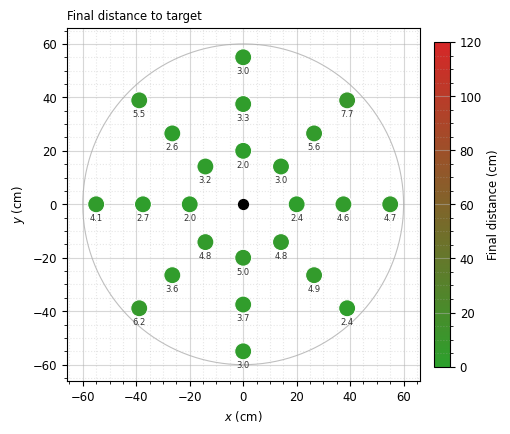

In [5]:
# ── 5. Display ────────────────────────────────────────────────────────────────
configure_screen()
fig = make_heatmap_figure(
    results, targets, arm_link=ARM_LINK,
    figsize=(5.0, 5.0),
)
apply_figure_style(fig)
plt.show()

In [6]:
# ── 6. PGF export ─────────────────────────────────────────────────────────────
FIG_WIDTH_FRAC  = 0.50
FIG_HEIGHT_FRAC = 0.32

configure_pgf()
fig = make_heatmap_figure(
    results, targets, arm_link=ARM_LINK,
    figsize=figure_inches(FIG_WIDTH_FRAC, FIG_HEIGHT_FRAC),
)
save_pgf(fig, FIGURES_PATH / "cartesian_control_heatmap.pgf")
plt.close(fig)

Saved to /Users/tahmidazam/Developer/gg4/figures/cartesian_control_heatmap.pgf


In [7]:
# ── 7. Caption ────────────────────────────────────────────────────────────────
import numpy as _np

final_dist = [r["dist"][-1] for r in results]
n_trials   = CC_N_R * CC_N_THETA

caption = (
    r"Final distance to target (cm) at each grid location for the "
    r"sequential open-loop controller. "
    f"{n_trials} targets on a {CC_N_R}\\texttimes{CC_N_THETA} polar grid "
    f"($r \\in [{CC_TARGET_R_MIN:.0f}, {CC_TARGET_R_MAX:.0f}]$\\,cm; "
    f"$T={CC_T}$ steps, seed {CC_DEMO_SEED}). "
    r"Dot colour encodes final Euclidean distance: green (0\,cm) to "
    r"red (\textgreater20\,cm). "
    r"The faint grey circle marks the arm reach boundary ($2l$ where "
    r"$l$ is the link length). "
    f"Mean final distance $= {_np.mean(final_dist):.1f}$\\,cm "
    f"(SD $= {_np.std(final_dist):.1f}$\\,cm)."
)

save_caption(CAPTIONS_PATH / "cartesian_control_heatmap.tex", caption, NOTEBOOK_GITHUB_URL)
print(caption)

Saved caption to /Users/tahmidazam/Developer/gg4/captions/cartesian_control_heatmap.tex
Final distance to target (cm) at each grid location for the sequential open-loop controller. 24 targets on a 3\texttimes8 polar grid ($r \in [20, 55]$\,cm; $T=1000$ steps, seed 0). Dot colour encodes final Euclidean distance: green (0\,cm) to red (\textgreater20\,cm). The faint grey circle marks the arm reach boundary ($2l$ where $l$ is the link length). Mean final distance $= 4.0$\,cm (SD $= 1.4$\,cm).
